# Customer analysis

We have a list of customers with their personal information and their behaviour.

We want to launch a new luxury and expensive product. 

Which customers should we target with personalized marketing?

# Task
- Perform basic data analysis and visualization
- Perform data editing (encoding)
- Select appropriate variables by which to segment customers
- Create a k-means model with an appropriate number of segments
- Visualize the model
- Which segment is the target segment?

# Data loading

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns  

In [2]:
data=pd.read_csv('../dataset/Mall_Customers.csv')

# Data description
- Information about the data
- Data preview
- Basic statistics
- View data distribution

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
data.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [5]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Data preparation
- Treatment of NaN values
- Encoding text columns

In [6]:
data.dropna()

#from sklearn import preprocessing
#label_encoder = preprocessing.LabelEncoder()
#data['Gender_enc']=label_encoder.fit_transform(data['Gender'])
genderEncoding = {"Male": 1, "Female": 2}
data['Gender_enc']= data['Gender'].map(genderEncoding)
data = data.drop(labels = 'Gender', axis = 1)
pass # M 1 | F 2

# Variable selection
- Displaying relationships between variables (pairplot)
- We are looking for a combination of variables that can be visually divided into groups
- Creating an X with only these columns

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

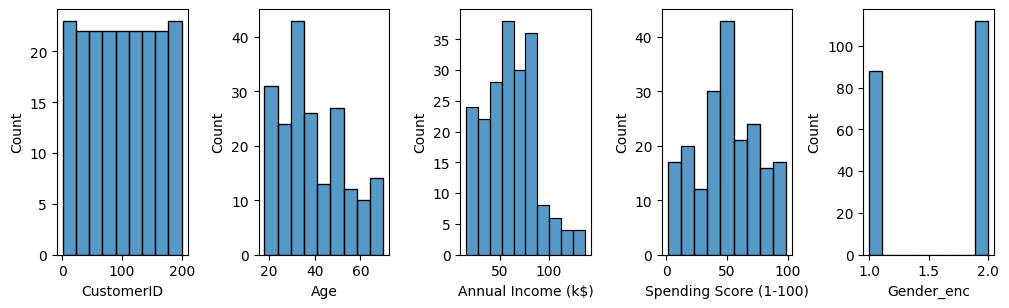

In [8]:
fig, axs = plt.subplots(ncols=5, nrows=1, figsize=(10, 3))
index = 0
axs = axs.flatten()
for k,v in data.items():
    #print(k)
    #print(v)
    #print(type(k))
    if k == "Gender":
        continue
    sns.histplot(v, ax=axs[index])
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)


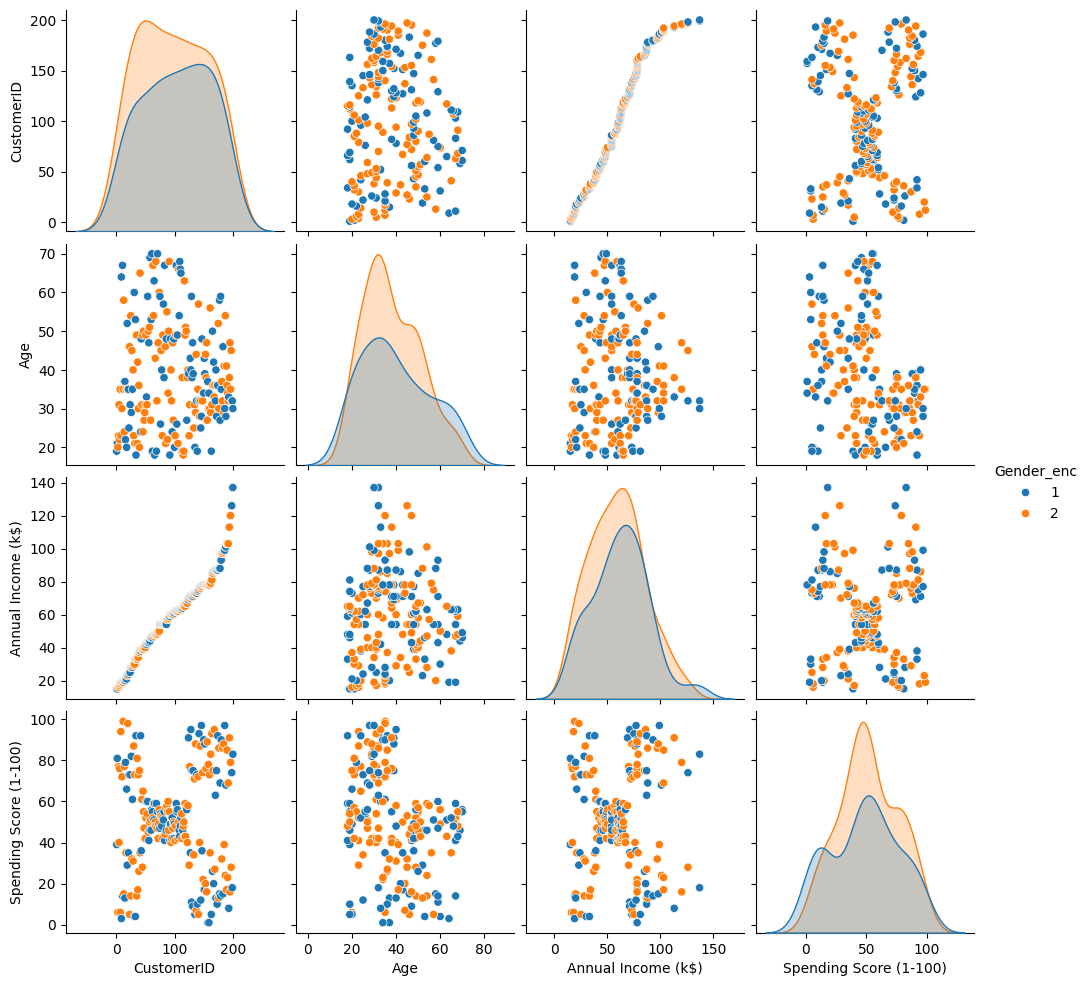

In [9]:

sns.pairplot(data, hue='Gender_enc', palette=sns.color_palette(n_colors=2))


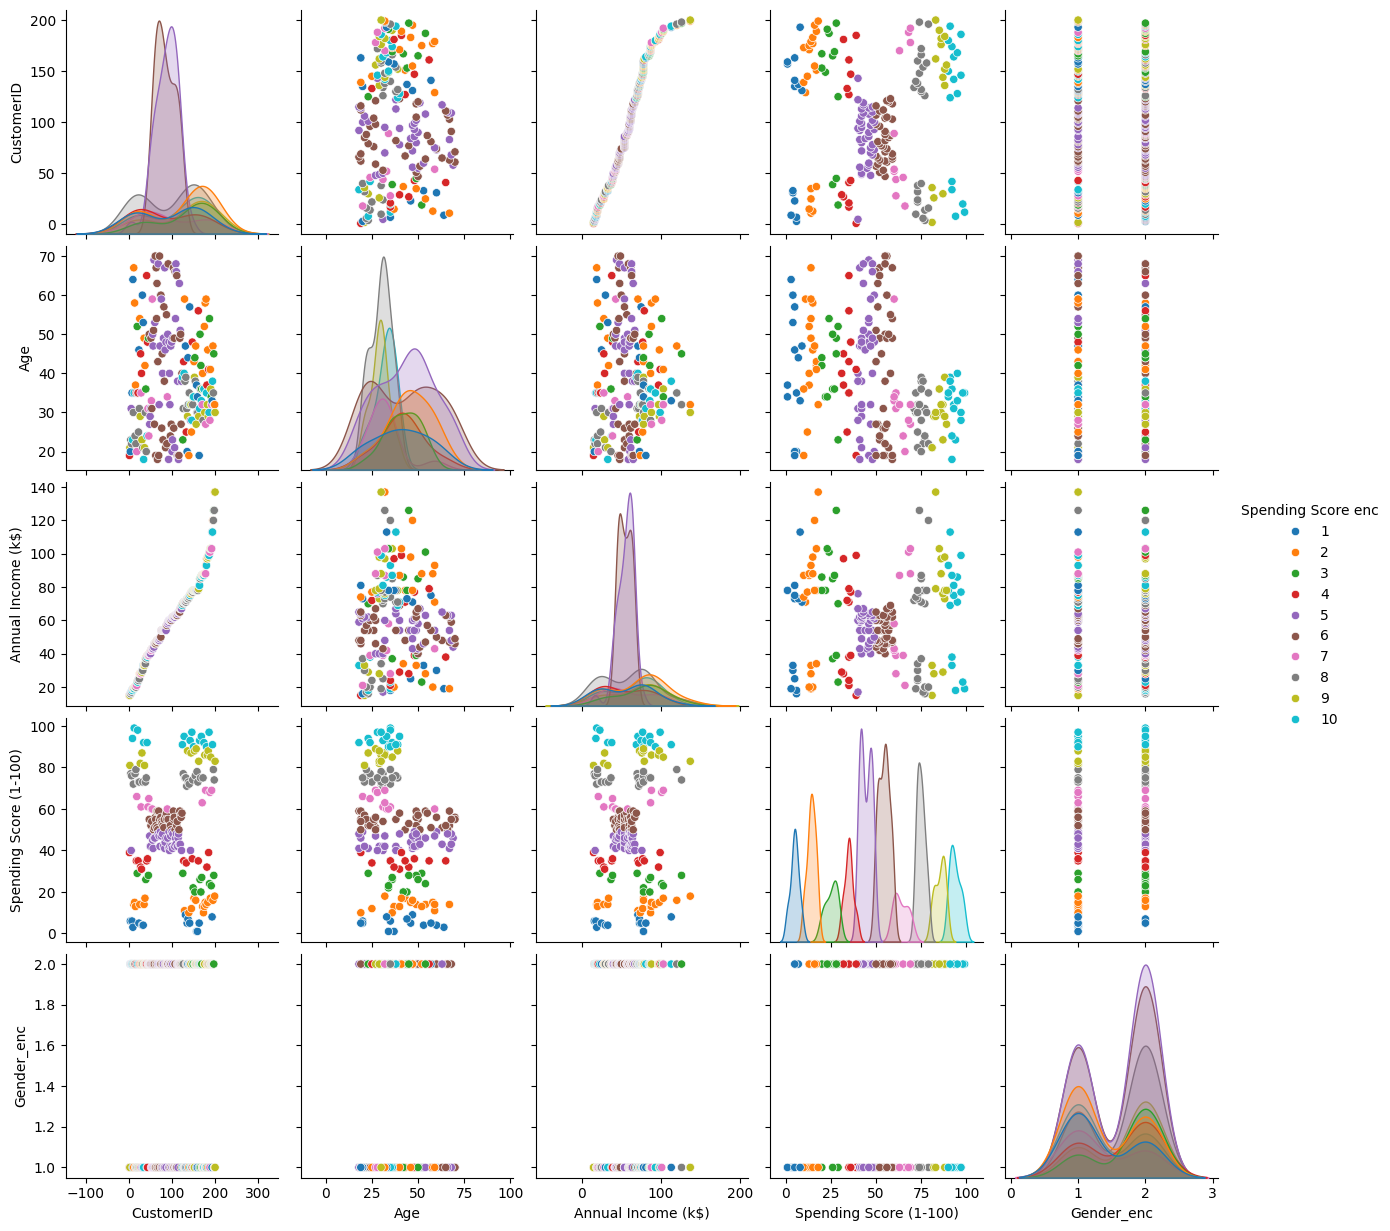

In [10]:
data_for_spending = data
spendingScoreEncoding = {i:int(i/10)+1 for i in range(1,101)}
data_for_spending['Spending Score enc']= data_for_spending['Spending Score (1-100)'].map(spendingScoreEncoding)

sns.pairplot(data_for_spending, hue='Spending Score enc', palette=sns.color_palette(n_colors=10))
#data = data.drop(labels = 'Spending Score (1-100)', axis = 1)

<Axes: >

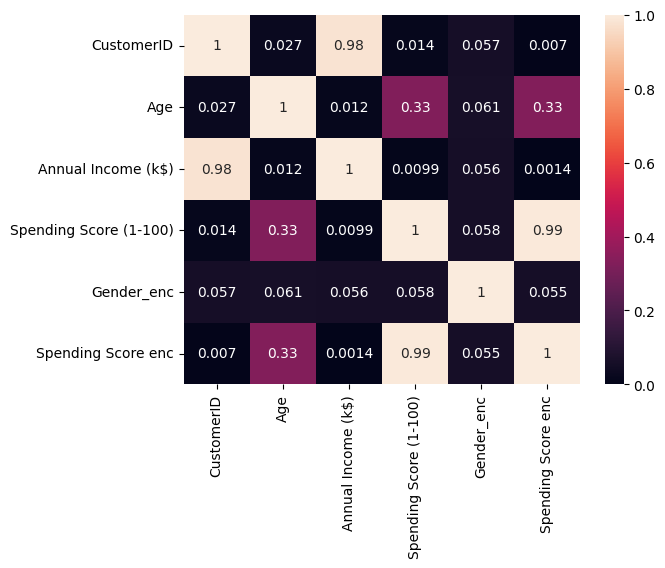

In [11]:
corr=data.corr()
sns.heatmap(corr.abs(), annot=True, vmin=0, vmax=1)

# Finding the k-mean model parameter
- Plotting elbow graph
- Finding the ideal number of clusters

In [12]:
X = data[['Age', 'Annual Income (k$)']].values # , 'CustomerID'
Y = data['Spending Score enc']

In [13]:

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split (X, Y, test_size=0.2)

In [14]:
from sklearn.cluster import KMeans
from scipy.stats import mode
from collections import Counter

maxNumOfClusters = 20

inertia_list = []
for num_clusters in range(1, maxNumOfClusters):
    kmeans_model = KMeans(n_clusters=num_clusters, init="k-means++", n_init = 10)
    kmeans_model.fit(X)
    inertia_list.append(kmeans_model.inertia_)

Text(0.5, 1.0, 'Different Inertia Values for Different Number of Clusters')

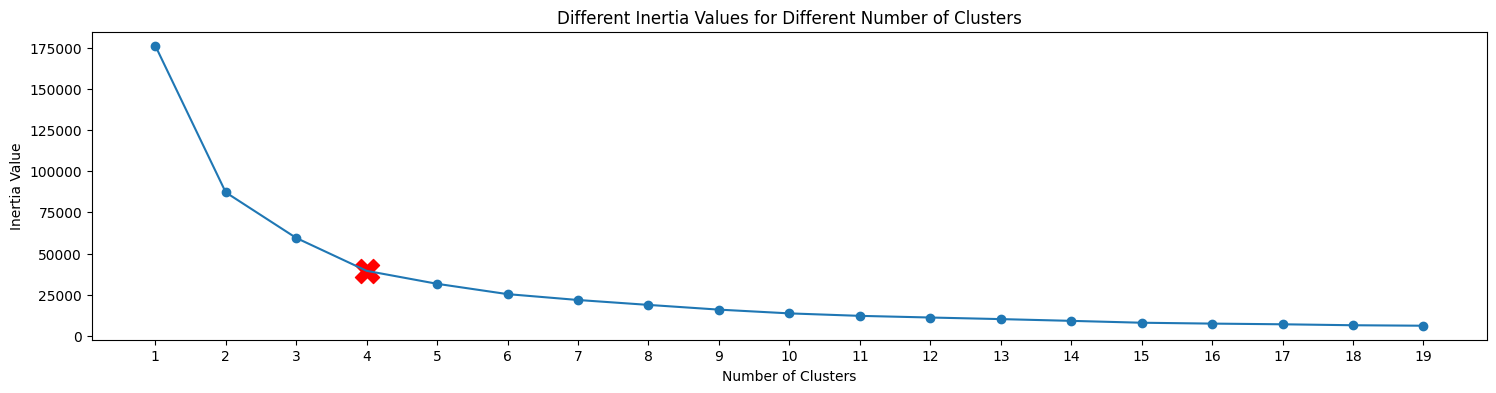

In [15]:
plt.figure(figsize=(18,4))
plt.plot(range(1,maxNumOfClusters),inertia_list)
plt.scatter(range(1,maxNumOfClusters),inertia_list)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia Value")
plt.xticks(np.arange(0, maxNumOfClusters, 1))
mark = 4 # 6
plt.scatter(mark, inertia_list[mark-1], marker="X", s=300, c="r")
plt.title("Different Inertia Values for Different Number of Clusters")

# k-mean model for the observed number of clusters
- Training the model
- Data prediction

In [16]:
kmean_model = KMeans(n_clusters=mark, random_state= None, n_init=100)
y_pred = kmean_model.fit(X_train)
kmean_model.cluster_centers_

array([[38.66666667, 99.63333333],
       [34.82926829, 29.51219512],
       [56.6       , 56.625     ],
       [29.75510204, 68.71428571]])

In [17]:
X_train

array([[ 26,  54],
       [ 23,  62],
       [ 28,  87],
       [ 57,  54],
       [ 29,  98],
       [ 38,  64],
       [ 19,  63],
       [ 49,  62],
       [ 24,  20],
       [ 35,  23],
       [ 40,  87],
       [ 44,  73],
       [ 19,  46],
       [ 66,  63],
       [ 59,  93],
       [ 54,  63],
       [ 70,  49],
       [ 49,  62],
       [ 35,  18],
       [ 67,  62],
       [ 29,  40],
       [ 65,  63],
       [ 52,  88],
       [ 18,  65],
       [ 48,  54],
       [ 45,  54],
       [ 26,  62],
       [ 50,  85],
       [ 58,  88],
       [ 32,  77],
       [ 39,  69],
       [ 48,  77],
       [ 45, 126],
       [ 64,  19],
       [ 60,  30],
       [ 36,  87],
       [ 22,  17],
       [ 30,  99],
       [ 32,  76],
       [ 32,  87],
       [ 18,  33],
       [ 31,  25],
       [ 30,  19],
       [ 27,  60],
       [ 27,  88],
       [ 20,  21],
       [ 51,  67],
       [ 31,  40],
       [ 18,  59],
       [ 65,  38],
       [ 19,  48],
       [ 27,  46],
       [ 47,

In [18]:
Y_pred_train = kmean_model.predict(X_train)
#Y_pred_test = kmean_model.predict(X_test)
Y_pred_train

array([3, 3, 0, 2, 0, 3, 3, 2, 1, 1, 0, 3, 1, 2, 0, 2, 2, 2, 1, 2, 1, 2,
       0, 3, 2, 2, 3, 0, 0, 3, 3, 3, 0, 1, 1, 0, 1, 0, 3, 0, 1, 1, 1, 3,
       0, 1, 2, 1, 3, 2, 3, 1, 0, 2, 2, 3, 2, 2, 2, 2, 3, 1, 1, 3, 1, 1,
       1, 3, 1, 1, 0, 0, 3, 3, 2, 0, 1, 3, 0, 0, 3, 1, 3, 2, 0, 0, 0, 2,
       3, 3, 0, 3, 2, 2, 1, 1, 1, 2, 1, 2, 3, 3, 1, 0, 3, 0, 2, 3, 1, 0,
       2, 1, 0, 3, 3, 3, 1, 3, 2, 1, 1, 1, 2, 3, 2, 3, 2, 3, 3, 3, 3, 0,
       2, 2, 0, 2, 2, 3, 2, 3, 3, 1, 2, 3, 2, 0, 0, 3, 1, 3, 3, 3, 2, 1,
       1, 1, 3, 2, 1, 1], dtype=int32)

In [19]:
X_train

array([[ 26,  54],
       [ 23,  62],
       [ 28,  87],
       [ 57,  54],
       [ 29,  98],
       [ 38,  64],
       [ 19,  63],
       [ 49,  62],
       [ 24,  20],
       [ 35,  23],
       [ 40,  87],
       [ 44,  73],
       [ 19,  46],
       [ 66,  63],
       [ 59,  93],
       [ 54,  63],
       [ 70,  49],
       [ 49,  62],
       [ 35,  18],
       [ 67,  62],
       [ 29,  40],
       [ 65,  63],
       [ 52,  88],
       [ 18,  65],
       [ 48,  54],
       [ 45,  54],
       [ 26,  62],
       [ 50,  85],
       [ 58,  88],
       [ 32,  77],
       [ 39,  69],
       [ 48,  77],
       [ 45, 126],
       [ 64,  19],
       [ 60,  30],
       [ 36,  87],
       [ 22,  17],
       [ 30,  99],
       [ 32,  76],
       [ 32,  87],
       [ 18,  33],
       [ 31,  25],
       [ 30,  19],
       [ 27,  60],
       [ 27,  88],
       [ 20,  21],
       [ 51,  67],
       [ 31,  40],
       [ 18,  59],
       [ 65,  38],
       [ 19,  48],
       [ 27,  46],
       [ 47,

In [20]:
labels_map = {}
for cluster in range(mark):
    #print(cluster)
    mask = (Y_pred_train == cluster)
    #print('mask')
    #print(mask)
    labels_map[cluster] = mode(Y_train[mask], keepdims=True).mode[0]
#TODO REWORK THIS


In [21]:
#Y_pred_train
labels_map

{0: np.int64(2), 1: np.int64(8), 2: np.int64(5), 3: np.int64(6)}

In [22]:
for id in range (0,mark):
    print (f"Cluster id {id}, encoding id: {labels_map[id]}, label: {id}")

Cluster id 0, encoding id: 2, label: 0
Cluster id 1, encoding id: 8, label: 1
Cluster id 2, encoding id: 5, label: 2
Cluster id 3, encoding id: 6, label: 3


# Visualization of the model
- Rendering of coloured groups of graphs

In [23]:
for i in range(mark):
    print(X_train[Y_pred_train == i, 1])
#print(X_train)
print(Y_pred_train)


[ 87  98  87  93  88  85  88 126  87  99  87  88 120 113  85 103 101  99
  86  87 103 126  88 113 120  93 101 137  98 103]
[20 23 46 18 40 19 30 17 33 25 19 21 40 46 25 33 28 34 29 28 39 20 19 28
 48 43 39 42 17 40 39 34 39 21 19 30 37 15 20 29 18]
[54 62 63 63 49 62 62 63 54 54 67 38 65 54 40 50 71 61 67 46 75 71 42 54
 54 54 60 47 43 59 58 60 79 50 48 47 43 63 48 65]
[54 62 64 63 73 65 62 77 69 77 76 60 59 48 77 81 57 73 78 77 64 78 67 61
 78 71 54 78 71 70 60 78 58 81 67 70 78 74 73 54 54 71 79 69 71 72 76 60
 78]
[3 3 0 2 0 3 3 2 1 1 0 3 1 2 0 2 2 2 1 2 1 2 0 3 2 2 3 0 0 3 3 3 0 1 1 0 1
 0 3 0 1 1 1 3 0 1 2 1 3 2 3 1 0 2 2 3 2 2 2 2 3 1 1 3 1 1 1 3 1 1 0 0 3 3
 2 0 1 3 0 0 3 1 3 2 0 0 0 2 3 3 0 3 2 2 1 1 1 2 1 2 3 3 1 0 3 0 2 3 1 0 2
 1 0 3 3 3 1 3 2 1 1 1 2 3 2 3 2 3 3 3 3 0 2 2 0 2 2 3 2 3 3 1 2 3 2 0 0 3
 1 3 3 3 2 1 1 1 3 2 1 1]


In [24]:
labels_map = {}
for cluster in range(4):
    mask = (Y_pred_train == cluster)
    labels_map[cluster] = mode(Y_train[mask], keepdims=True).mode[0]
labels_map

{0: np.int64(2), 1: np.int64(8), 2: np.int64(5), 3: np.int64(6)}

In [25]:
#x_idToGrup = {X_train[i][1]:Y_pred_train[i] for i in range(0,len(Y_pred_train))}#ID
#x_idToGrup

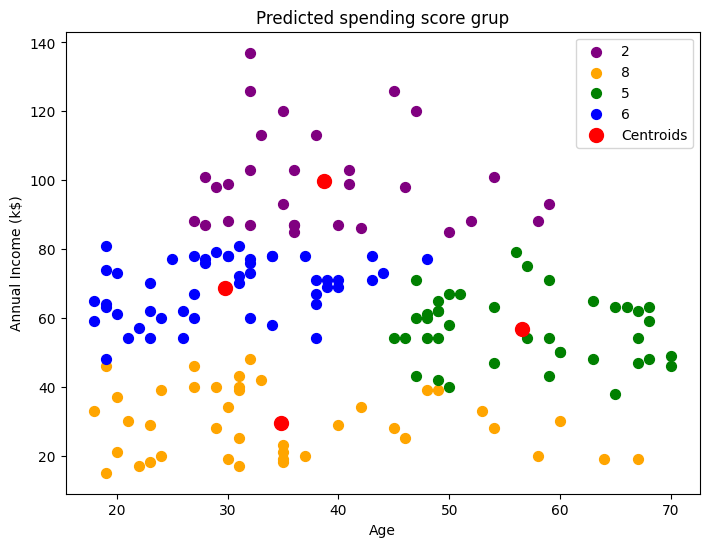

In [26]:
plt.figure(figsize=(18,6))
#plt.subplot(1,2,1)
color = ['orange','blue','green','cyan','pink','brown','purple','yellow']
{}
if False:
    plt.subplot(1,2,2)
    for customer in data[['Spending Score (1-100)', 'CustomerID', 'Annual Income (k$)']].values:
        try:
            colorID = x_idToGrup[customer[1]]-1
        except KeyError:
            print(customer[1])
            continue
        plt.scatter(customer[0], customer[2], s = 50, c = color[colorID])
    #plt.scatter(kmean_model.cluster_centers_[:, 0], kmean_model.cluster_centers_[:,1], s = 100, c = 'red', label = 'Centroids')
    plt.title('Spending score'); plt.xlabel('X'); plt.ylabel('Y')
if False:
    plt.subplot(1,2,1)
    ax = plt.axes(projection = '3d')
    for i in range(mark):
        ax.scatter(X_train[Y_pred_train == i, 0], X_train[Y_pred_train == i, 1], X_train[Y_pred_train == i, 2], s = 50, c = color[i], label = str(i+1))
    ax.scatter(kmean_model.cluster_centers_[:, 0], kmean_model.cluster_centers_[:,1], kmean_model.cluster_centers_[:,2], s = 100, c = 'red', label = 'Centroids')
    plt.title('Spending score'); 
    ax.set_xlabel('Age')
    ax.set_ylabel('Annual Income (k$)')
    ax.set_zlabel('CustomerID')
    ax.legend()

    # prediction    
#    ax = plt.add_subplot(1,2,1, projection='3d')
#    ax = plt.axes(projection = '3d')
#    ax.scatter(X_train[Y_pred_train == 0, 0], X_train[Y_pred_train == 0, 1], X_train[Y_pred_train == 0, 2], s = 50, c = 'purple', label = 'One')
#    ax.scatter(X_train[Y_pred_train == 1, 0], X_train[Y_pred_train == 1, 1], X_train[Y_pred_train == 1, 2], s = 50, c = 'orange', label = 'two')
#    ax.scatter(X_train[Y_pred_train == 2, 0], X_train[Y_pred_train == 2, 1], X_train[Y_pred_train == 2, 2], s = 50, c = 'green', label = 'three')
#    ax.scatter(X_train[Y_pred_train == 3, 0], X_train[Y_pred_train == 3, 1], X_train[Y_pred_train == 3, 2], s = 50, c = 'blue', label = 'four')
#    ax.scatter(X_train[Y_pred_train == 4, 0], X_train[Y_pred_train == 4, 1], X_train[Y_pred_train == 4, 2], s = 50, c = 'yellow', label = 'five')
#    plt.title('Predicted spending score grup')
#    ax.xlabel('Age')
#    ax.ylabel('Annual Income (k$)')
#    ax.zlabel('CustomerID') 
#    # centroid
#    ax.scatter(kmean_model.cluster_centers_[:, 0], kmean_model.cluster_centers_[:,1], kmean_model.cluster_centers_[:,2], s = 100, c = 'red', label = 'Centroids')
#    ax.legend()

    ## real values
    #plt.subplot(1,2,2)
    #plt.scatter(X_train[Y_train == labels_map[0], 0], X_train[Y_train == labels_map[0], 1], s = 50, c = 'purple', label = 'Iris-setosa')
    #plt.scatter(X_train[Y_train == labels_map[1], 0], X_train[Y_train == labels_map[1], 1], s = 50, c = 'orange', label = 'Iris-versicolour')
    #plt.scatter(X_train[Y_train == labels_map[2], 0], X_train[Y_train == labels_map[2], 1], s = 50, c = 'green', label = 'Iris-virginica')
    #plt.title('True Species'); plt.xlabel('petal_length'); plt.ylabel('petal_width')
    #
    #plt.legend()
else:
    plt.subplot(1,2,1)
    #ax = plt.axes(projection = '2d')
    plt.scatter(X_train[Y_pred_train == 0, 0], X_train[Y_pred_train == 0, 1], s = 50, c = 'purple', label = str(labels_map[0]))
    plt.scatter(X_train[Y_pred_train == 1, 0], X_train[Y_pred_train == 1, 1], s = 50, c = 'orange', label = str(labels_map[1]))
    plt.scatter(X_train[Y_pred_train == 2, 0], X_train[Y_pred_train == 2, 1], s = 50, c = 'green', label = str(labels_map[2]))
    plt.scatter(X_train[Y_pred_train == 3, 0], X_train[Y_pred_train == 3, 1], s = 50, c = 'blue', label = str(labels_map[3]))
    #plt.scatter(X_train[Y_pred_train == 4, 0], X_train[Y_pred_train == 4, 1], s = 50, c = 'pink', label = 'five')
    plt.title('Predicted spending score grup'); plt.xlabel('Age'); plt.ylabel('Annual Income (k$)')
    plt.scatter(kmean_model.cluster_centers_[:, 0], kmean_model.cluster_centers_[:,1], s = 100, c = 'red', label = 'Centroids')
    plt.legend()
    

In [27]:
#X = data[['Age', 'Annual Income (k$)']].values # , 'CustomerID'
#Y = data['Spending Score enc']
X_test
kmean_model.predict(X_test)

array([2, 2, 2, 3, 0, 3, 1, 1, 3, 1, 2, 3, 0, 0, 3, 1, 3, 3, 1, 0, 2, 3,
       2, 2, 1, 2, 1, 3, 1, 1, 1, 3, 3, 1, 3, 1, 3, 2, 0, 0], dtype=int32)

## Interpretation of the model
- Describe each group
- Which customers to target?

In [28]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_enc,Spending Score enc
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,1.560000,5.570000
std,57.879185,13.969007,26.264721,25.823522,0.497633,2.576488
min,1.000000,18.000000,15.000000,1.000000,1.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000,1.000000,4.000000
50%,100.500000,36.000000,61.500000,50.000000,2.000000,6.000000
75%,150.250000,49.000000,78.000000,73.000000,2.000000,8.000000
max,200.000000,70.000000,137.000000,99.000000,2.000000,10.000000


In [29]:
dataPred = data.copy(True)
dataPred['Pred'] = kmean_model.predict(dataPred[['Age', 'Annual Income (k$)']].values)


In [30]:
for i in dataPred['Pred'].unique():
    print('grup:', str(labels_map[i]))
    print(dataPred[dataPred['Pred'] == i].describe())

grup: 8
       CustomerID        Age  Annual Income (k$)  Spending Score (1-100)  \
count   53.000000  53.000000           53.000000               53.000000   
mean    27.981132  33.792453           28.622642               50.018868   
std     17.140248  12.722419            9.460904               29.305087   
min      1.000000  18.000000           15.000000                3.000000   
25%     14.000000  23.000000           20.000000               28.000000   
50%     27.000000  31.000000           28.000000               51.000000   
75%     40.000000  40.000000           37.000000               75.000000   
max     70.000000  67.000000           48.000000               99.000000   

       Gender_enc  Spending Score enc  Pred  
count   53.000000           53.000000  53.0  
mean     1.622642            5.566038   1.0  
std      0.489364            2.951593   0.0  
min      1.000000            1.000000   1.0  
25%      1.000000            3.000000   1.0  
50%      2.000000            6.

- grup 2: small, spending score around 50, not good enought
- grup 6: big, spending score around 45, small deviation around 55 years old, income around 51.300 k. bad grup
- grup 5: middle size, good spending score, around 31 years old, income 70.000 k. good grup
- grup 8: middle size, income around 29.500k, around 29 year old, spending score great.

Grup numbers may change, but characteristics will stay simmilar.
